# Cluster Visualization (UMAP)

Notebook version: **entropy + centroid overlay** (updated).

This notebook projects document embeddings into 2D using UMAP and visualizes:
1. Dominant fuzzy cluster assignments with projected centroids
2. Uncertainty using normalized entropy


In [27]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import umap

ROOT = Path(r"c:\Users\sruja\OneDrive\Desktop\trademarkia")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.clustering import FuzzyClusterModel
from app.config import SETTINGS
from app.vector_store import LocalVectorDB

print("python:", sys.executable)
print("project_root:", ROOT)


python: c:\Users\sruja\OneDrive\Desktop\trademarkia\.venv\Scripts\python.exe
project_root: c:\Users\sruja\OneDrive\Desktop\trademarkia


In [28]:
vector_db = LocalVectorDB.load(SETTINGS.vector_store_path)
cluster_model = FuzzyClusterModel.load(SETTINGS.clustering_path)

X_embeddings = vector_db.embeddings
labels = cluster_model.labels
memberships = cluster_model.memberships

print('documents:', X_embeddings.shape[0])
print('embedding_dim:', X_embeddings.shape[1])
print('selected_clusters:', cluster_model.n_clusters)


documents: 19829
embedding_dim: 256
selected_clusters: 28


In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import numpy as np

docs = [row['cleaned_text'] for row in vector_db.metadata]
hard_labels = cluster_model.labels
n_clusters = cluster_model.n_clusters

cluster_docs = []
for c in range(n_clusters):
    cluster_text = ' '.join(docs[i] for i in range(len(docs)) if hard_labels[i] == c)
    cluster_docs.append(cluster_text)

vectorizer = CountVectorizer(
    stop_words='english',
    min_df=10,
    max_df=0.4,
    ngram_range=(1, 2),
    max_features=30000,
)

X_bow = vectorizer.fit_transform(cluster_docs)
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_bow)

terms = vectorizer.get_feature_names_out()
top_k = 10

print('\nTop keywords per cluster (c-TF-IDF):\n')
for cluster_id in range(n_clusters):
    row = X_tfidf[cluster_id].toarray().flatten()
    top_idx = row.argsort()[-top_k:][::-1]
    keywords = [terms[i] for i in top_idx]
    print(f"Cluster {cluster_id:02d} -> {', '.join(keywords)}")



Top keywords per cluster (c-TF-IDF):

Cluster 00 -> circuit, modems, bps, pins, circuits, ink, dsp, shack, printers, interrupt
Cluster 01 -> catholic, biblical, worship, doctrine, orthodox, passage, marriage, divine, arrogance, luke
Cluster 02 -> morality, morals, objectively, jew, societal, hudson, goodness, mathew subject, terrorist, abortion
Cluster 03 -> abortion, clayton, sept, msg, reform, deaths, islamic, democratic, funding, ban
Cluster 04 -> isa, vga, vesa, slots, slot, stealth, controllers, macs, nec, parity
Cluster 05 -> blues, detroit, kings, cape, stevens, champions, cherry, mario, slot, sweep
Cluster 06 -> toolkit, app, mit edu, anonymous ftp, interactive, edu pub, lcs, icon, gui, den
Cluster 07 -> koresh, myers, reno, attorney, assault, raid, janet, tanks, followers, suicide
Cluster 08 -> occupied, soldiers, civilians, jew, iraq, gulf, islamic, troops, racial, terrorist
Cluster 09 -> mph, motor, dodge, shifting, fluid, seats, detector, mercury, retail, noisy
Cluster 10 

In [30]:
sample_size = 6000
rng = np.random.default_rng(42)
idx = rng.choice(X_embeddings.shape[0], size=min(sample_size, X_embeddings.shape[0]), replace=False)

X_sample = X_embeddings[idx]
labels_sample = labels[idx]
membership_sample = memberships[idx]

num_clusters = membership_sample.shape[1]
entropy = -(membership_sample * np.log(membership_sample + 1e-12)).sum(axis=1)
entropy_norm = entropy / np.log(num_clusters)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.05,
    metric='cosine',
    random_state=42,
)
X_2d = reducer.fit_transform(X_sample)

centers_2d = np.zeros((num_clusters, 2), dtype=np.float32)
center_present = np.zeros(num_clusters, dtype=bool)
for c in range(num_clusters):
    mask = labels_sample == c
    if np.any(mask):
        centers_2d[c] = X_2d[mask].mean(axis=0)
        center_present[c] = True

print('UMAP shape:', X_2d.shape)
print('Centroids available:', int(center_present.sum()), '/', num_clusters)


c:\Users\sruja\OneDrive\Desktop\trademarkia\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (6000, 2)
Centroids available: 28 / 28


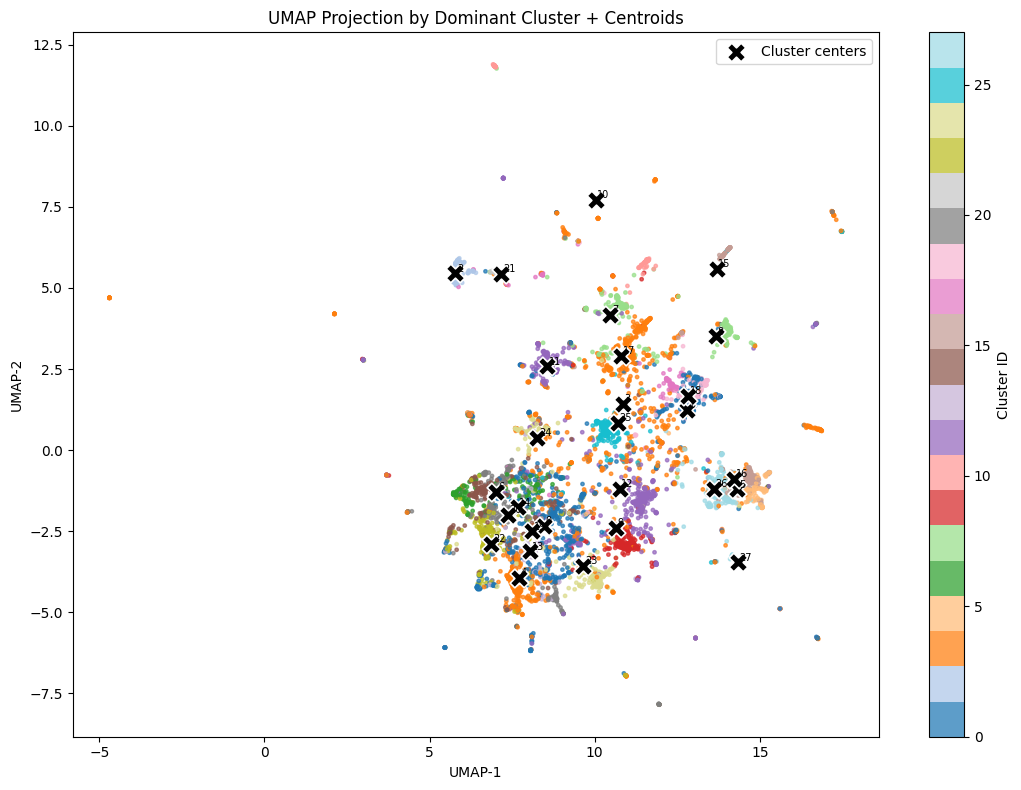

In [31]:
plt.figure(figsize=(11, 8))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_sample,
    s=6,
    cmap='tab20',
    alpha=0.72,
)

valid_ids = np.where(center_present)[0]
valid_centers = centers_2d[valid_ids]
plt.scatter(
    valid_centers[:, 0],
    valid_centers[:, 1],
    marker='X',
    c='black',
    s=180,
    edgecolors='white',
    linewidths=1.2,
    label='Cluster centers',
)
for cid, (cx, cy) in zip(valid_ids, valid_centers):
    plt.text(cx + 0.05, cy + 0.05, str(cid), fontsize=7, color='black')

plt.title('UMAP Projection by Dominant Cluster + Centroids')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(scatter, label='Cluster ID')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


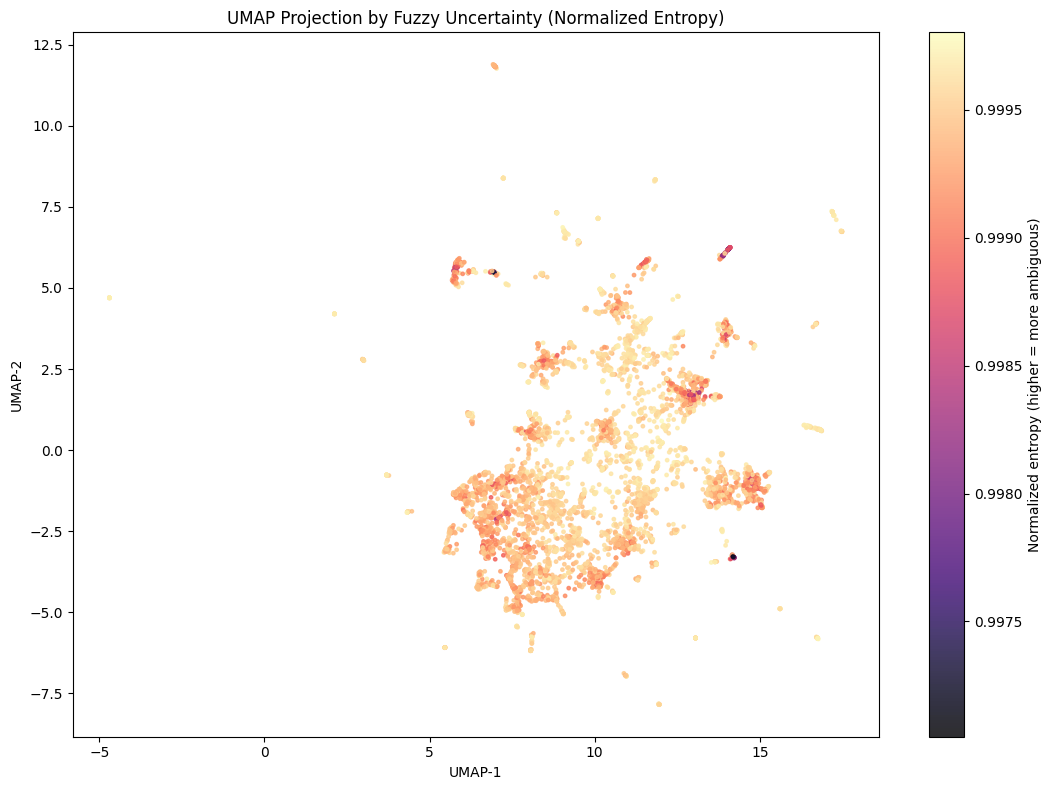

In [32]:
plt.figure(figsize=(11, 8))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=entropy_norm,
    s=6,
    cmap='magma',
    alpha=0.82,
)
plt.title('UMAP Projection by Fuzzy Uncertainty (Normalized Entropy)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(scatter, label='Normalized entropy (higher = more ambiguous)')
plt.tight_layout()
plt.show()

## Interpretation Notes
- Compact regions with consistent colors indicate coherent semantic clusters.
- Black `X` markers show cluster centers projected into the same UMAP space.
- Higher normalized entropy indicates boundary cases where documents plausibly belong to multiple clusters.